# Understanding the Data Context: A Guide to Professional Cycling Data
Welcome to the world of professional cycling! Before we can build a model to predict race winners, we need to understand the sport and the data that describes it. This notebook will explain the key concepts so that anyone can understand the context behind our project for CAICLE.

In [42]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [ ]:
# set paths relative to this notebook
db_path = "../../data/cycling_big.db"
riders_csv_path = "../../data /data/rider_infos.csv"
team_urls_path = "../../data/data/team_urls/"

In [52]:
# define csv and sql into a df, ignore the many csv files because they are the same thing as sql
ride = pd.read_csv(riders_csv_path)

conn = sqlite3.connect(db_path)
race = pd.read_sql_query("SELECT * FROM race_results", conn)
conn.close()

## What is Professional Road Cycling?


At its core, professional cycling is about riders on bicycles competing to cross a finish line first. However, it's far more complex than just a simple race. It's a sport of immense strategy, teamwork, and specialized physical abilities.

Races can be broadly divided into two types:

1. One-Day Races ("Classics"): These are single-day events, often covering very long distances (200-270 km). The objective is simple: be the first rider to cross the finish line.

2. Stage Races ("Tours"): These are multi-day events, lasting anywhere from a few days to three weeks. The famous Tour de France, Giro d'Italia, and Vuelta a España are the "Grand Tours" and are the most prestigious.

In a stage race, there are two main competitions happening at once:

 - The Stage Win: The prize for winning that single day's race.

 - The General Classification (GC): The prize for the rider with the lowest cumulative time across all stages. This is the ultimate prize, and the leader of the GC wears a special jersey (like the famous Yellow Jersey in the Tour de France).

In [49]:
# groupby race_name to get stage_number
stage_counts = race.groupby('Race_Name')['Stage_Number'] \
.nunique().reset_index()

display(stage_counts.sort_values('Stage_Number').head(3))

,Race_Name,Stage_Number
0,AG Driedaagse Brugge-De Panne ME,1
3,Amstel Gold Race,1
6,Bretagne Classic - Ouest-France,1


In [50]:
# make extra column to classify
stage_counts['Race_Type'] = stage_counts['Stage_Number'].apply(
    lambda x: 'Classic' if x == 1 else 'Tour')

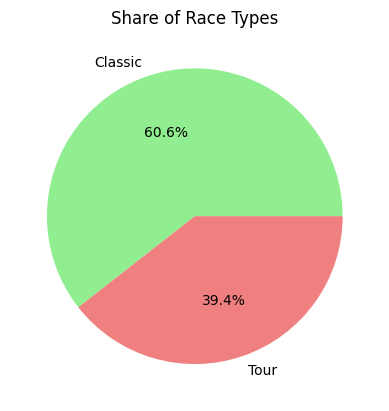

In [51]:
# simple pie plot
stage_counts['Race_Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['lightgreen', 'lightcoral']
)
plt.title('Share of Race Types')
plt.ylabel('')  # remove y-axis label
plt.show()

Ive made a simple pie plot to see the 2 race types and we can see that we have more classis races than tour ones.

---

## It’s a Team Sport, Not an Individual One
The most important thing to understand is that while only one rider wins, professional cycling is a team sport. Each team has a designated leader they are trying to help win. The other riders, known as "domestiques," have specific jobs:

- Protecting the leader from the wind by letting them draft.

- Chasing down attacking riders from other teams.

- Getting food and water for the leader.

This is crucial for our project because a very strong rider might finish 50th, not because they performed poorly, but because their job was to work hard for their leader who finished on the podium.

## Rider Roles are Dynamic and Change Stage-by-Stage

A rider's role is not fixed for an entire tour. It's adapted daily based on the stage's profile and the team's strategy.

* **Flat Stages :** The team's best **sprinter** becomes the leader for the day. Their goal is to win the stage in a bunch sprint. The GC contenders and climbers switch to a domestique role, working to protect the sprinter.

* **Mountain Stages :** The team's best **climber** or **General Classification (GC)** contender becomes the leader. Their goal is to gain time on rivals or win the stage. Now, the sprinters become domestiques.

Let's prove this with data. We will automatically classify the roles for our chosen team on two different stages of the race: one likely flat stage and one likely mountain stage.

---

## Not All Riders Are the Same: The Specialists
Cycling is a team sport where riders have highly specialized roles, much like in soccer. A team needs a mix of specialists to succeed. Our data, especially the pps (ProCyclingStats Points) column, helps us identify these roles.

1. Climbers: These are lightweight, lean riders who excel on steep mountain roads. Their goal is to win mountain stages and compete for the overall General Classification (GC) in big tours. You'll see from the data that top climbers like Alejandro Valverde and Nairo Quintana often have lower weight.

2. Sprinters: These are powerful, muscular riders who can produce explosive bursts of speed over short distances. Their goal is to win flat stages by outsprinting everyone in the final few hundred meters. Riders like Mark Cavendish and André Greipel are legendary sprinters.

3. Time Trialists: These specialists excel at riding alone against the clock. This is measured in the Stage_Type column as 'ITT' (Individual Time Trial). They are often strong contenders for the GC.

4. All-Rounders ("Puncheurs"): These riders are versatile and can perform well on various terrains, especially on short, steep hills. They are valuable assets for any team. Riders like Peter Sagan and Wout van Aert are famous for their versatility.

---

Now, let's look at the most important columns in our data and what they mean in the context of a bike race.

- Rnk (Rank): This is one of the most important features It tells us where a rider finished on a specific day (in a stage). A rank of '1' means they won. A 'DNF' (Did Not Finish) means they dropped out.

- GC (General Classification): This is the rider's overall rank in a multi-day tour. This will be blank for one-day races and for riders who are far behind in a tour. A low GC number is very prestigious.

- Race_Name: This tells us the importance of the event. A good result in the Tour de France is far more valuable than one in a smaller race.

- Stage_Type: This tells us the nature of the day's race.

- RR (Road Race): A standard race with a mass start.

- ITT (Individual Time Trial): A race against the clock. Rider performance can vary drastically between these types.

- Length: The distance of the race in kilometers. A rider's ability can depend on the race length; some excel in shorter, more intense races, while others are built for long endurance events.

- pps and rdr: These are crucial columns containing scraped data about a rider's skills. The pps column contains scores for specialties like 'Climber', 'Sprint', and 'Time Trial', which we've extracted. This is a direct data representation of the rider archetypes discussed above.

- height and weight: Physical attributes that are highly correlated with a rider's specialty. Climbers are typically lighter, while sprinters may be heavier due to their larger muscle mass.

- Age: A critical factor. This helps us assess a rider's future potential versus their current form.

---

## Our Goal: Connecting the Dots
Our mission for CAICLE is to use this data to build a predictive model. By combining a rider's specialty (pps), their physical attributes (height, weight), their age, and their past performance (Rnk, GC) in important races (Race_Name) on different types of terrain (Stage_Type, Length), we can predict their likelihood of future success.

This will allow CAICLE to move beyond simple rankings and make smarter, data-driven decisions to build their cycling super team.

---